## Testing Methods in the `TRACTTOOLS` Module

This Jupyter Notebook serves as a platform to test the various methods included in the Python module `TRACTTOOLS`.

This module is particularly valuable for researchers working with diffusion MRI tractography: loading and manipulating tractograms (`.trk`, `.tck`), attaching scalar maps per streamline or per point, clustering streamlines into bundles and computing their centroids, filtering, resampling and smoothing streamlines, interpolating volumetric metrics (e.g. FA) along the tracts, and visualizing the results.

The tests are organized into the following sections for clarity and ease of navigation:

* **🔷 0. [Tractogram Simulation](#tractogram-class_simulate)**: Simulate synthetic tractograms to use them in tests and examples.
  * 🔸 0.1. [simulate_tractogram](#tractogram-simulate_tractogram): Simulate a synthetic tractogram inside the space of a reference NIfTI image.
* **🔷 1. [Tractogram Class](#tractogram-class)**: Main class to represent and manipulate tractograms. Initialize a Tractogram object from a tractogram file.
  * 🔸 1.1. [load_tractogram_from_file](#tractogram-load_tractogram_from_file): Load a tractogram file and extract streamlines, affine transformation and header information.
  * 🔸 1.2. [load_tractogram_from_object](#tractogram-load_tractogram_from_object): Load a tractogram from a nibabel Tractogram object.
  * 🔸 1.3. [load_colortable](#tractogram-load_colortable): Load a colortable from a file and associate it with a specified map name.
  * 🔸 1.4. [smooth_streamlines](#tractogram-smooth_streamlines): Smooth streamlines using a Gaussian filter.
  * 🔸 1.5. [resample_streamlines](#tractogram-resample_streamlines): Resample streamlines to a specified number of points.
  * 🔸 1.6. [get_info](#tractogram-get_info): Display comprehensive information about the tractogram.
  * 🔸 1.7. [streamline_to_points](#tractogram-streamline_to_points): Convert maps_per_streamline to maps_per_point by assigning the streamline value to all its points.
  * 🔸 1.8. [points_to_streamline](#tractogram-points_to_streamline): Convert maps_per_point to maps_per_streamline by averaging point values for each streamline.
  * 🔸 1.9. [add_tractogram](#tractogram-add_tractogram): Merge the current Tractogram with one or more other Tractogram objects.
  * 🔸 1.10. [compute_centroids](#tractogram-compute_centroids): Extract bundle centroids from the tractogram and save them as .trk files.
  * 🔸 1.11. [label_streamlines_by_clusters](#tractogram-label_streamlines_by_clusters): Label each streamline in the tractogram with its corresponding cluster ID.
  * 🔸 1.12. [get_cluster_streamlines](#tractogram-get_cluster_streamlines): Retrieve the streamlines belonging to a specific cluster.
  * 🔸 1.13. [compute_streamline_lengths](#tractogram-compute_streamline_lengths): Compute the lengths of all streamlines in the tractogram.
  * 🔸 1.14. [interpolate_on_tractogram](#tractogram-interpolate_on_tractogram): Interpolate scalar values (e.g. FA) from a NIfTI image onto this tractogram.
  * 🔸 1.15. [get_pointwise_colors](#tractogram-get_pointwise_colors): Compute streamlines colors for visualization based on the specified overlay.
  * 🔸 1.16. [reduce_streamlines](#tractogram-reduce_streamlines): Reduce the number of streamlines by a specified factor.
  * 🔸 1.17. [filter](#tractogram-filter): Filter streamlines based on their lengths.
  * 🔸 1.18. [list_maps](#tractogram-list_maps): List all available scalar maps in the tractogram.
  * 🔸 1.19. [get_maps_info](#tractogram-get_maps_info): Retrieve information about the scalar maps stored in the tractogram.
  * 🔸 1.20. [get_tractogram_info](#tractogram-get_tractogram_info): Retrieve basic information about the tractogram object.
  * 🔸 1.21. [apply_affine](#tractogram-apply_affine): Apply an affine transformation to all streamlines in the tractogram.
  * 🔸 1.22. [centroids_to_tractogram](#tractogram-centroids_to_tractogram): Convert the computed centroids into a new tractogram object.
  * 🔸 1.23. [save_tractogram](#tractogram-save_tractogram): Save the tractogram to a specified file.
  * 🔸 1.24. [plot](#tractogram-plot): Plot the tractogram with the specified overlay and visualization parameters.
  * 🔸 1.25. [simulate_tractogram (advanced options)](#tractogram-simulate): Control the number, shape, orientation and location of the simulated bundles.


* **🔷 2. [Other methods](#tract-other_methods)**: Other methods to manipulate tractograms outside the Tractogram class.
  * 🔸 2.1. [resample_streamlines](#tract-resample_streamlines): Resample streamlines to a specified number of points.
  * 🔸 2.2. [interpolate_streamline_values](#tract-interpolate_streamline_values): Interpolate values from original streamline coordinates to new coordinates.
  * 🔸 2.3. [merge_tractograms](#tract-merge_tractograms): Merge multiple tractograms into a single tractogram.
  * 🔸 2.4. [trk2tck](#tract-trk2tck): Convert a .trk tractogram to .tck format.
  * 🔸 2.5. [tck2trk](#tract-tck2trk): Convert a .tck tractogram to .trk format using a reference NIfTI image.

---

## <a id="tractogram-class_simulate" name="tractogram-class_simulate"></a>🔷 0. Tractogram simulation

Simulate synthetic tractograms to use them in tests and examples.


### <a id="tractogram-simulate_tractogram" name="tractogram-simulate_tractogram"></a>🔸 0.1. simulate_tractogram

Simulate a synthetic tractogram inside the space of a reference NIfTI image.

---


In [1]:
######################## Testing the simulate_tractogram method ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg

# Test 1: Simulating a reference image and a tractogram from it
print("Test 1: Simulating a Tractogram from a simulated reference image...")
simulated_image="/tmp/simulated_image.nii.gz"
ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)
tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 
print("Tractogram loaded successfully.")
print("Tractogram details:")
tract_obj.get_info()
tract_obj.plot(overlay_name="bundle_id")

# Test 2: Simulating a tractogram with different number of bundles
print("Test 2: Simulating a Tractogram with different number of bundles...")
tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, n_bundles=10) 
print("Tractogram loaded successfully.")
tract_obj.plot(overlay_name="bundle_id")

# Test 3: Simulating a tractogram with a specific number of streamlines
print("Test 3: Simulating a Tractogram with a specific number of streamlines...")
tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, 
                                                    n_bundles=1, 
                                                    n_streamlines=5000) 
print("Tractogram loaded successfully.")
tract_obj.plot(overlay_name="bundle_id")

# Test 4: Simulating a tractogram with both a specific number of bundles and streamlines.
print("Test 4: Simulating a Tractogram with both a specific number of bundles and streamlines...")
tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, 
                                                    n_bundles=5, 
                                                    n_streamlines=50,
                                                    noise=0.1) 
print("Tractogram loaded successfully.")
tract_obj.plot(overlay_name="bundle_id")



Test 1: Simulating a Tractogram from a simulated reference image...
Successfully created simulated image:
  Reference shape: (100, 100, 70)
  Output shape: (100, 100, 70)
  Non-zero voxels: 700,000
  Distribution: normal
  Saved to: /tmp/simulated_image.nii.gz


Output()

Tractogram loaded successfully.
Tractogram details:
╔════════════════════════════════════════════════════════════════╗
║                     TRACTOGRAM EXPLORATION                     ║
╠════════════════════════════════════════════════════════════════╣
║ Name: simulated                                                ║
║ Streamlines: 500                                               ║
╠════════════════════════════════════════════════════════════════╣
║ AFFINE TRANSFORMATION MATRIX                                   ║
║   [[1. 0. 0. 0.]                                               ║
║    [0. 1. 0. 0.]                                               ║
║    [0. 0. 1. 0.]                                               ║
║    [0. 0. 0. 1.]]                                              ║
╠════════════════════════════════════════════════════════════════╣
║ HEADER INFORMATION                                             ║
║   Origin:        0.00 × 0.00 × 0.00                            ║
╠═════════

Output()

Tractogram loaded successfully.
Number of views: 1, Number of maps: 1, Number of objects: 1
Test 3: Simulating a Tractogram with a specific number of streamlines...


Output()

Tractogram loaded successfully.
Number of views: 1, Number of maps: 1, Number of objects: 1
Test 4: Simulating a Tractogram with both a specific number of bundles and streamlines...


Output()

Tractogram loaded successfully.
Number of views: 1, Number of maps: 1, Number of objects: 1


## <a id="tractogram-class" name="tractogram-class"></a>🔷 1. Tractogram class

Main class to represent and manipulate tractograms. Initialize a Tractogram object from a tractogram file.


In [2]:
######################## Testing the Tractogram class ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"

    print("Loading tractogram from file:", in_trk)
    tract_obj = clttract.Tractogram(in_trk)

print("Tractogram loaded successfully.")
print("Tractogram details:")
tract_obj.get_info()
tract_obj.plot()

Loading tractogram from file: /opt/freesurfer/trctrain/hcp/mni/cc.bodyc.display.trk
Tractogram loaded successfully.
Tractogram details:
╔════════════════════════════════════════════════════════════════╗
║                     TRACTOGRAM EXPLORATION                     ║
╠════════════════════════════════════════════════════════════════╣
║ Name: default                                                  ║
║ Streamlines: 1,005                                             ║
╠════════════════════════════════════════════════════════════════╣
║ AFFINE TRANSFORMATION MATRIX                                   ║
║   [[1. 0. 0. 0.]                                               ║
║    [0. 1. 0. 0.]                                               ║
║    [0. 0. 1. 0.]                                               ║
║    [0. 0. 0. 1.]]                                              ║
╠════════════════════════════════════════════════════════════════╣
║ HEADER INFORMATION                                        

### <a id="tractogram-load_tractogram_from_file" name="tractogram-load_tractogram_from_file"></a>🔸 1.1. load_tractogram_from_file

Load a tractogram file and extract streamlines, affine transformation and header information.

---


In [3]:
######################## Testing load_tractogram_from_file ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 
    in_trk = "/tmp/simulated_tractogram.trk"
    tract_obj.save_tractogram(in_trk, overwrite=True)

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"

print("Loading tractogram from file:", in_trk)

# The method loads the file into the object and also returns its content
tract_obj = clttract.Tractogram()
tracts, affine, header, data_per_point, data_per_streamline = tract_obj.load_tractogram_from_file(in_trk)

print("Tractogram loaded successfully.")
print("Tractogram details:")
print("Number of streamlines:", len(tract_obj.tracts))
print("Affine matrix:\n", tract_obj.affine)
print("Maps per point     :", list(data_per_point.keys()))
print("Maps per streamline:", list(data_per_streamline.keys()))


Loading tractogram from file: /opt/freesurfer/trctrain/hcp/mni/cc.bodyc.display.trk
Loading tractogram from file: /opt/freesurfer/trctrain/hcp/mni/cc.bodyc.display.trk
Tractogram loaded successfully.
Tractogram details:
Number of streamlines: 1005
Affine matrix:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Maps per point     : []
Maps per streamline: ['ValidEndpts', 'TruncatedLength', 'DistanceRank', 'length']


### <a id="tractogram-load_tractogram_from_object" name="tractogram-load_tractogram_from_object"></a>🔸 1.2. load_tractogram_from_object

Load a tractogram from a nibabel Tractogram object.

---


In [4]:
######################## Testing load_tractogram_from_object ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os
import nibabel as nb

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 
    in_trk = "/tmp/simulated_tractogram.trk"
    tract_obj.save_tractogram(in_trk, overwrite=True)

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"

# Reading the file with nibabel to obtain a nibabel Tractogram object
trk_file = nb.streamlines.load(in_trk)
nib_tractogram = trk_file.tractogram

print("Loading tractogram from a nibabel Tractogram object")
tract_obj = clttract.Tractogram()
tract_obj.load_tractogram_from_object(nib_tractogram)

print("Number of streamlines:", len(tract_obj.tracts))
print("Maps per streamline:", list(tract_obj.data_per_streamline.keys()))
print("Affine matrix:\n", tract_obj.affine)

# The header belongs to the file object, so it is empty unless it is attached to
# the Tractogram object before loading it
print("\nHeader read from the object:", tract_obj.header)

nib_tractogram.header = trk_file.header
tract_obj = clttract.Tractogram(nib_tractogram)
print("Header after attaching it to the object:")
print("  Image dimensions:", tract_obj.header["dimensions"])
print("  Voxel sizes     :", tract_obj.header["voxel_sizes"])


Loading tractogram from a nibabel Tractogram object
Number of streamlines: 1005
Maps per streamline: ['ValidEndpts', 'TruncatedLength', 'DistanceRank', 'length']
Affine matrix:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Header read from the object: {}
Header after attaching it to the object:
  Image dimensions: [182 218 182]
  Voxel sizes     : [1. 1. 1.]


### <a id="tractogram-load_colortable" name="tractogram-load_colortable"></a>🔸 1.3. load_colortable

Load a colortable from a file and associate it with a specified map name.

---


In [5]:
######################## Testing load_colortable ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os
import numpy as np

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 30 mm
    tract_obj_1  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=30) 

    # Simulating a tractogram with 5 bundles of length 60 mm
    tract_obj_2  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=60) 

    # Merging the two simulated tractograms into a single tractogram object
    tract_obj = clttract.merge_tractograms([tract_obj_1, tract_obj_2])

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    
    tract_obj = clttract.Tractogram(in_trk)

# Creating a categorical map: short (0) and long (1) streamlines
lengths = tract_obj.compute_streamline_lengths()
length_group = (lengths > np.median(lengths)).astype(int)
tract_obj.data_per_streamline["length_group"] = length_group.reshape(-1, 1)

# The colortable can be a LUT/TSV file or a dictionary with index, name and color keys
lut_dict = {
    "index": [0, 1],
    "name": ["short_streamlines", "long_streamlines"],
    "color": ["#1f77b4", "#d62728"],
}

print("Loading the colortable for the map 'length_group'...")
tract_obj.load_colortable(lut_dict, map_name="length_group", opacity=1.0)

print("Region names:", tract_obj.colortables["length_group"]["names"])
print("Color table (R, G, B, alpha, value):")
print(tract_obj.colortables["length_group"]["color_table"])
print("\nAvailable colortables:", list(tract_obj.colortables.keys()))
tract_obj.plot(overlay_name="length_group")

Loading the colortable for the map 'length_group'...
Region names: ['short_streamlines', 'long_streamlines']
Color table (R, G, B, alpha, value):
[[ 31. 119. 180.   1.   0.]
 [214.  39.  40.   1.   1.]]

Available colortables: ['default', 'length_group']
Number of views: 1, Number of maps: 1, Number of objects: 1


### <a id="tractogram-smooth_streamlines" name="tractogram-smooth_streamlines"></a>🔸 1.4. smooth_streamlines

Smooth streamlines using a Gaussian filter.

---


In [6]:
######################## Testing smooth_streamlines ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import clabtoolkit.visualizationtools as cltvis
import os
import copy

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 30 mm and noise 0.20
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=30, noise=0.20) 
    map_name = "bundle_id"
else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)
    tract_obj.compute_streamline_lengths()
    map_name = "length"

# Making a copy of the original tractogram for comparison after smoothing
tract_obj_original = copy.deepcopy(tract_obj)

print("Smoothing the streamlines with a Gaussian filter...")
tract_obj.smooth_streamlines(iterations=20, sigma=1.5)

print("Visualizing the original and smoothed tractograms...")
plotter = cltvis.BrainPlotter()
plotter.plot([tract_obj_original, tract_obj], map_names=map_name, use_opacity=False)

Smoothing the streamlines with a Gaussian filter...


Visualizing the original and smoothed tractograms...
Number of views: 1, Number of maps: 1, Number of objects: 2


### <a id="tractogram-resample_streamlines" name="tractogram-resample_streamlines"></a>🔸 1.5. resample_streamlines

Resample streamlines to a specified number of points.

---


In [7]:
######################## Testing resample_streamlines ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles (default parameters)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

print("Number of points per streamline before resampling:")
print([len(st) for st in tract_obj.tracts[:5]], "...")

# Resampling all the streamlines to the same number of points
resampled = tract_obj.resample_streamlines(nb_points=30, interp_method="linear")

print("\nNumber of streamlines after resampling:", len(resampled))
print("Shape of the first resampled streamline:", np.asarray(resampled[0]).shape)
print("Number of points per streamline after resampling:")
print([len(st) for st in resampled[:5]], "...")


Number of points per streamline before resampling:
[129, 120, 130, 122, 121] ...

Number of streamlines after resampling: 1005
Shape of the first resampled streamline: (30, 3)
Number of points per streamline after resampling:
[30, 30, 30, 30, 30] ...


### <a id="tractogram-get_info" name="tractogram-get_info"></a>🔸 1.6. get_info

Display comprehensive information about the tractogram.

---


In [8]:
######################## Testing get_info ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles (default parameters)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

# Printing a comprehensive report of the tractogram content
tract_obj.get_info()


╔════════════════════════════════════════════════════════════════╗
║                     TRACTOGRAM EXPLORATION                     ║
╠════════════════════════════════════════════════════════════════╣
║ Name: default                                                  ║
║ Streamlines: 1,005                                             ║


╠════════════════════════════════════════════════════════════════╣
║ AFFINE TRANSFORMATION MATRIX                                   ║
║   [[1. 0. 0. 0.]                                               ║
║    [0. 1. 0. 0.]                                               ║
║    [0. 0. 1. 0.]                                               ║
║    [0. 0. 0. 1.]]                                              ║
╠════════════════════════════════════════════════════════════════╣
║ HEADER INFORMATION                                             ║
║   Origin:        0.00 × 0.00 × 0.00                            ║
╠════════════════════════════════════════════════════════════════╣
║ SCALAR DATA PER POINT (0 maps)                                 ║
║   No scalar data available                                     ║
╠════════════════════════════════════════════════════════════════╣
║ SCALAR DATA PER STREAMLINE (5 maps)                            ║
║   ValidEndpts   Min:     3.00     Max:     3.00            

### <a id="tractogram-streamline_to_points" name="tractogram-streamline_to_points"></a>🔸 1.7. streamline_to_points

Convert maps_per_streamline to maps_per_point by assigning the streamline value to all its points.

---


In [9]:
######################## Testing streamline_to_points ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles (default parameters)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

# Test 1: Converting streamline data to point data
print("Test 1: Converting streamline data to point data")

# Compute the lengths of all streamlines in the tractogram before converting to point data
tract_obj.compute_streamline_lengths()

print("Maps per point before the conversion:", tract_obj.list_maps()["maps_per_point"])

# Every point of a streamline inherits the value of its own streamline
point_data = tract_obj.streamline_to_points(map_name="length", point_map_name="length_per_point")

print("Maps per point after the conversion :", tract_obj.list_maps()["maps_per_point"])
print("\nLength of the first streamline:", tract_obj.data_per_streamline["length"][0])
print("Values of its first 5 points     :", np.asarray(point_data[0])[:5].ravel())
print("Number of points of the first streamline:", len(point_data[0]))


Test 1: Converting streamline data to point data
Maps per point before the conversion: []
Maps per point after the conversion : ['length_per_point']

Length of the first streamline: [126.30379]
Values of its first 5 points     : [126.30379 126.30379 126.30379 126.30379 126.30379]
Number of points of the first streamline: 129


### <a id="tractogram-points_to_streamline" name="tractogram-points_to_streamline"></a>🔸 1.8. points_to_streamline

Convert maps_per_point to maps_per_streamline by averaging point values for each streamline.

---


In [10]:
######################## Testing points_to_streamline ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles (default parameters)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)


# Test 1: Converting point data to streamline data
print("Test 1: Converting point data to streamline data")

# Creating a pointwise map (FA sampled along each streamline)
tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name)

# Collapsing the pointwise values into a single value per streamline
fa_mean = tract_obj.points_to_streamline(map_name=map_name, streamline_map_name=f"{map_name}_mean", metric="mean")
fa_median = tract_obj.points_to_streamline(map_name=map_name, streamline_map_name=f"{map_name}_median", metric="median")

print("Shape of the aggregated array:", fa_mean.shape)
print("Mean value of the first 5 streamlines  :", fa_mean[:5].ravel())
print("Median value of the first 5 streamlines:", fa_median[:5].ravel())
print("\nMaps per streamline:", tract_obj.list_maps()["maps_per_streamline"])


Test 1: Converting streamline data to point data
Shape of the aggregated array: (1005, 1)
Mean value of the first 5 streamlines  : [0.4719213  0.446139   0.51765691 0.46228122 0.39772682]
Median value of the first 5 streamlines: [0.51817533 0.52337    0.55484494 0.57712654 0.4684893 ]

Maps per streamline: ['ValidEndpts', 'TruncatedLength', 'DistanceRank', 'length', 'default', 'fa_mean', 'fa_median']


### <a id="tractogram-add_tractogram" name="tractogram-add_tractogram"></a>🔸 1.9. add_tractogram

Merge the current Tractogram with one or more other Tractogram objects.

---


In [11]:
######################## Testing add_tractogram ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os
import numpy as np

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 30 mm
    tract_obj_1  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=30) 

    # Simulating a tractogram with 5 bundles of length 60 mm
    tract_obj_2  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=60) 

else:
    in_trk1 = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    in_trk2 = f"{freesurfer_home}/trctrain/hcp/mni/cc.genu.display.trk"

    tract_obj_1 = clttract.Tractogram(in_trk1)
    tract_obj_2 = clttract.Tractogram(in_trk2)

# Assigning a different color to each tractogram
tract_obj_1.set_color("#731010")
tract_obj_2.set_color("#2A25D0")

print("Number of streamlines in the first tractogram :", len(tract_obj_1.tracts))
print("Number of streamlines in the second tractogram:", len(tract_obj_2.tracts))

# Merging both tractograms into a new object
merged_obj = tract_obj_1.add_tractogram(tract_obj_2)

print("\nNumber of streamlines in the merged tractogram:", len(merged_obj.tracts))
print("Maps per streamline:", merged_obj.list_maps()["maps_per_streamline"])
print("Tract IDs found in the merged tractogram:", np.unique(merged_obj.data_per_streamline["tract_id"]))
merged_obj.plot(overlay_name="default")

Number of streamlines in the first tractogram : 1005
Number of streamlines in the second tractogram: 1006

Number of streamlines in the merged tractogram: 2011
Maps per streamline: ['length', 'DistanceRank', 'TruncatedLength', 'ValidEndpts', 'default', 'tract_id']
Tract IDs found in the merged tractogram: [0 1]
Number of views: 1, Number of maps: 1, Number of objects: 1


### <a id="tractogram-compute_centroids" name="tractogram-compute_centroids"></a>🔸 1.10. compute_centroids

Extract bundle centroids from the tractogram and save them as .trk files.

---


In [12]:
######################## Testing compute_centroids ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 60 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=60) 


else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

# QuickBundles clustering (only the first threshold is used)
print("Computing the centroids using QuickBundles...")
centroids, centroids_indexes = tract_obj.compute_centroids(method="qb")

print("Number of centroids:", len(centroids))
print("Number of streamlines per cluster:", [len(ind) for ind in centroids_indexes[:5]], "...")

# QuickBundlesX clustering (multi-resolution, it uses all the thresholds)
print("\nComputing the centroids using QuickBundlesX...")
centroids_qbx, centroids_indexes_qbx = tract_obj.compute_centroids(method="qbx", thresholds=[20, 15, 10])

print("Number of centroids:", len(centroids_qbx))
print("Shape of the first centroid:", np.asarray(centroids_qbx[0]).shape)


Computing the centroids using QuickBundles...
Number of centroids: 40
Number of streamlines per cluster: [24, 61, 28, 80, 29] ...

Computing the centroids using QuickBundlesX...
Number of centroids: 103
Shape of the first centroid: (12, 3)


### <a id="tractogram-label_streamlines_by_clusters" name="tractogram-label_streamlines_by_clusters"></a>🔸 1.11. label_streamlines_by_clusters

Label each streamline in the tractogram with its corresponding cluster ID.

---


In [13]:
######################## Testing label_streamlines_by_clusters ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 60 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=60) 


else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

# The clusters must be computed before labelling the streamlines
tract_obj.compute_centroids(method="qb", thresholds=[10])

cluster_ids = tract_obj.label_streamlines_by_clusters()

print("Number of labelled streamlines:", len(cluster_ids))
print("Cluster IDs:", np.unique(cluster_ids))
print("Cluster ID of the first 10 streamlines:", cluster_ids[:10])
print("\nA colortable is created automatically for the map 'cluster_id':")
print("Cluster names:", tract_obj.colortables["cluster_id"]["names"][:5], "...")
print("Maps per streamline:", tract_obj.list_maps()["maps_per_streamline"])


Number of labelled streamlines: 1005
Cluster IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Cluster ID of the first 10 streamlines: [0 1 2 1 0 1 3 4 3 5]

A colortable is created automatically for the map 'cluster_id':
Cluster names: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4'] ...
Maps per streamline: ['ValidEndpts', 'TruncatedLength', 'DistanceRank', 'length', 'default', 'cluster_id']


### <a id="tractogram-get_cluster_streamlines" name="tractogram-get_cluster_streamlines"></a>🔸 1.12. get_cluster_streamlines

Retrieve the streamlines belonging to a specific cluster.

---


In [14]:
######################## Testing get_cluster_streamlines ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 60 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=60) 


else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)
    
tract_obj.compute_centroids(method="qb", thresholds=[10])

# Retrieving the streamlines belonging to a single cluster
cluster_streamlines = tract_obj.get_cluster_streamlines(cluster_id=0)

print("Number of clusters:", len(tract_obj.centroids))
print("Number of streamlines in cluster 0:", len(cluster_streamlines))
print("Shape of the first streamline of the cluster:", np.asarray(cluster_streamlines[0]).shape)

# Number of streamlines for the first clusters
for cluster_id in range(min(5, len(tract_obj.centroids))):
    n_streamlines = len(tract_obj.get_cluster_streamlines(cluster_id=cluster_id))
    print(f"Cluster {cluster_id}: {n_streamlines} streamlines")


Number of clusters: 40
Number of streamlines in the cluster 0: 24
Shape of the first streamline of the cluster: (129, 3)
Cluster 0: 24 streamlines
Cluster 1: 61 streamlines
Cluster 2: 28 streamlines
Cluster 3: 80 streamlines
Cluster 4: 29 streamlines


### <a id="tractogram-compute_streamline_lengths" name="tractogram-compute_streamline_lengths"></a>🔸 1.13. compute_streamline_lengths

Compute the lengths of all streamlines in the tractogram.

---


Shape of the lengths array: (1005, 1)
Minimum length: 85.64 mm
Maximum length: 140.13 mm
Mean length   : 118.47 mm


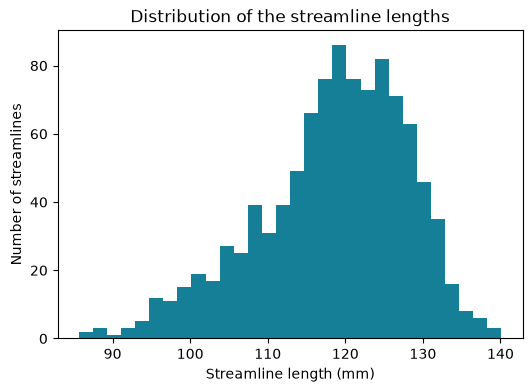

In [15]:
######################## Testing compute_streamline_lengths ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import matplotlib.pyplot as plt
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 60 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=60) 

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

# The lengths are returned and also stored in data_per_streamline["length"]
lengths = tract_obj.compute_streamline_lengths()

print("Shape of the lengths array:", lengths.shape)
print(f"Minimum length: {lengths.min():.2f} mm")
print(f"Maximum length: {lengths.max():.2f} mm")
print(f"Mean length   : {lengths.mean():.2f} mm")

# Plotting the distribution of the streamline lengths
plt.figure(figsize=(6, 4))
plt.hist(lengths, bins=30, color="#157F97")
plt.xlabel("Streamline length (mm)")
plt.ylabel("Number of streamlines")
plt.title("Distribution of the streamline lengths")
plt.show()


### <a id="tractogram-interpolate_on_tractogram" name="tractogram-interpolate_on_tractogram"></a>🔸 1.14. interpolate_on_tractogram

Interpolate scalar values (e.g. FA) from a NIfTI image onto this tractogram.

---


In [16]:
######################## Testing interpolate_on_tractogram ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles (default parameters)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)


# Test 1: One value per point (stored in data_per_point[map_name])
print("Test 1: Interpolating the map values at every point of the streamlines...")

# Creating a pointwise map (FA sampled along each streamline)
tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name, storage_mode="data_per_point", interp_method="linear")

print("Maps per point:", tract_obj.list_maps()["maps_per_point"])
print("Interpolated values along the first streamline:", np.asarray(tract_obj.data_per_point[map_name][0])[:5].ravel())

# Test 2: One value per streamline (stored in data_per_streamline[f"{map_name}_mean"])
print("\nTest 2: Interpolating the map and reducing it per streamline...")
tract_obj.interpolate_on_tractogram(image_for_interp, storage_mode="data_per_streamline", map_name=map_name, reduction="mean")

print("Maps per streamline:", tract_obj.list_maps()["maps_per_streamline"])
print("Mean of the first 5 streamlines:", tract_obj.data_per_streamline[f"{map_name}_mean"][:5].ravel())


Test 1: Converting streamline data to point data
Maps per point: ['fa']
Interpolated values along the first streamline: [0.04623812 0.05458993 0.07685225 0.13379299 0.18559752]

Test 2: Interpolating the map and reducing it per streamline...
Maps per streamline: ['ValidEndpts', 'TruncatedLength', 'DistanceRank', 'length', 'default', 'fa_mean']
Mean of the first 5 streamlines: [0.4719213  0.446139   0.51765691 0.46228122 0.39772682]


### <a id="tractogram-get_pointwise_colors" name="tractogram-get_pointwise_colors"></a>🔸 1.15. get_pointwise_colors

Compute streamlines colors for visualization based on the specified overlay.

---


In [17]:
######################## Testing get_pointwise_colors ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles (default parameters)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)


# Creating a pointwise map (FA sampled along each streamline)
tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name)


# Test 1: Scalar overlay. The colors are computed with a continuous colormap
print("Test 1: Colors for a scalar overlay ...")
point_colors = tract_obj.get_pointwise_colors(overlay_name=map_name, colormap="hot")
print("Number of colored streamlines:", len(point_colors))
print("Colors of the first 3 points of the first streamline:\n", np.asarray(point_colors[0])[:3])

# Test 2: Categorical overlay. The colors are taken from the associated colortable
print("\nTest 2: Colors for a categorical overlay (cluster_id)...")
tract_obj.compute_centroids(method="qb", thresholds=[10])
tract_obj.label_streamlines_by_clusters()
point_colors = tract_obj.get_pointwise_colors(overlay_name="cluster_id")
print("Colors of the first 3 points of the first streamline:\n", np.asarray(point_colors[0])[:3])
tract_obj.plot(overlay_name="cluster_id")

# Test 3: Restricting the range. The values outside it are painted with range_color
print("\nTest 3: Restricting the range of the values...")
point_colors = tract_obj.get_pointwise_colors(overlay_name=map_name, colormap="hot", range_min=0.3, range_max=0.8, range_color=(128, 128, 128, 255))
print("Colors of the first 3 points of the first streamline:\n", np.asarray(point_colors[0])[:3])


Test 1: Converting streamline data to point data
Test 1: Colors for a scalar overlay ...
Number of colored streamlines: 1005
Colors of the first 3 points of the first streamline:
 [[42  0  0]
 [47  0  0]
 [60  0  0]]

Test 2: Colors for a categorical overlay (cluster_id)...
Colors of the first 3 points of the first streamline:
 [[177  53  50   1]
 [177  53  50   1]
 [177  53  50   1]]
Number of views: 1, Number of maps: 1, Number of objects: 1

Test 3: Restricting the range of the  values...
Colors of the first 3 points of the first streamline:
 [[128 128 128]
 [128 128 128]
 [128 128 128]]


### <a id="tractogram-reduce_streamlines" name="tractogram-reduce_streamlines"></a>🔸 1.16. reduce_streamlines

Reduce the number of streamlines by a specified factor.

---


In [18]:
######################## Testing reduce_streamlines ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles (default parameters)
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image) 
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)


######################## Reducing the number of streamlines ###################################
print("Test 1: Reducing the number of streamlines")
print("Number of streamlines before the reduction:", len(tract_obj.tracts))

# The tractogram is modified in place, keeping approximately the specified percentage
tract_obj.reduce_streamlines(percentage=25)

print("Number of streamlines after keeping the 25%:", len(tract_obj.tracts))
print("Number of streamlines stored in the header  :", tract_obj.header["nb_streamlines"])
print("Length of the maps per streamline           :", len(tract_obj.data_per_streamline["length"]))


Test 1: Reducing the number of streamlines
Number of streamlines before the reduction: 1005
Number of streamlines after keeping the 25%: 252
Number of streamlines stored in the header  : 252
Length of the maps per streamline           : 252


### <a id="tractogram-filter" name="tractogram-filter"></a>🔸 1.17. filter

Filter streamlines based on their lengths.

---


In [19]:
######################## Testing filter ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import copy
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 150 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=150) 
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

lengths = tract_obj.compute_streamline_lengths()

# Keeping an unfiltered copy, because filter modifies the object in place
tract_obj_original = copy.deepcopy(tract_obj)

print("Number of streamlines:", len(tract_obj.tracts))
print(f"Streamline lengths between {lengths.min():.2f} and {lengths.max():.2f} mm")

# Test 1: Keeping the streamlines inside a range of lengths
print("\nTest 1: Filtering the streamlines with lengths between 120 and 130 mm...")
filtered_streamlines = tract_obj.filter(condition="120 < length < 130")
print("Number of streamlines kept:", len(tract_obj.tracts))

# Test 2: A single comparison can also be used
print("\nTest 2: Filtering the streamlines longer than 125 mm...")
tract_obj = copy.deepcopy(tract_obj_original)
filtered_streamlines = tract_obj.filter(condition="length > 125")
print("Number of streamlines kept:", len(tract_obj.tracts))


Number of streamlines: 1005
Streamline lengths between 85.64 and 140.13 mm

Test 1: Filtering the streamlines with lengths between 120 and 130 mm...
Filtered 387 streamlines matching condition: 120 < length < 130
Number of streamlines kept: 387

Test 2: Filtering the streamlines longer than 125 mm...
Filtered 272 streamlines matching condition: length > 125
Number of streamlines kept: 272


### <a id="tractogram-list_maps" name="tractogram-list_maps"></a>🔸 1.18. list_maps

List all available scalar maps in the tractogram.

---


In [20]:
######################## Testing list_maps ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)


maps_dict = tract_obj.list_maps()
print("Maps stored in the file:")
print("  Maps per point     :", maps_dict["maps_per_point"])
print("  Maps per streamline:", maps_dict["maps_per_streamline"])

# Adding a new pointwise map
tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name)

maps_dict = tract_obj.list_maps()
print("\nMaps after interpolating the map:")
print("  Maps per point     :", maps_dict["maps_per_point"])
print("  Maps per streamline:", maps_dict["maps_per_streamline"])


Maps stored in the file:
  Maps per point     : []
  Maps per streamline: ['ValidEndpts', 'TruncatedLength', 'DistanceRank', 'length', 'default']

Maps after interpolating the map:
  Maps per point     : ['fa']
  Maps per streamline: ['ValidEndpts', 'TruncatedLength', 'DistanceRank', 'length', 'default']


### <a id="tractogram-get_maps_info" name="tractogram-get_maps_info"></a>🔸 1.19. get_maps_info

Retrieve information about the scalar maps stored in the tractogram.

---


In [21]:
######################## Testing get_maps_info ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os
import itables


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)


maps_dict = tract_obj.list_maps()
print("Maps stored in the file:")
print("  Maps per point     :", maps_dict["maps_per_point"])
print("  Maps per streamline:", maps_dict["maps_per_streamline"])

# Adding a new pointwise map
tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name)

# The information of all the maps is returned as a pandas DataFrame
maps_info = tract_obj.get_maps_info()

itables.show(maps_info) 


Maps stored in the file:
  Maps per point     : []
  Maps per streamline: ['ValidEndpts', 'TruncatedLength', 'DistanceRank', 'length', 'default']


Loading ITables v2.8.0 from the internet... (need help?)


### <a id="tractogram-get_tractogram_info" name="tractogram-get_tractogram_info"></a>🔸 1.20. get_tractogram_info

Retrieve basic information about the tractogram object.

---


In [22]:
######################## Testing get_tractogram_info ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)

# Adding a new pointwise map
tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name)

tract_info = tract_obj.get_tractogram_info()

print("Keys of the dictionary:", list(tract_info.keys()))
print("\nNumber of streamlines   :", tract_info["number_of_streamlines"])
print(f"Mean streamline length  : {tract_info['mean_streamline_length']:.2f} mm")
print("Affine matrix:\n", tract_info["affine"])
print("\nImage dimensions:", tract_info["header"]["dimensions"])
print("Voxel sizes     :", tract_info["header"]["voxel_sizes"])


Keys of the dictionary: ['number_of_streamlines', 'mean_streamline_length', 'affine', 'header']

Number of streamlines   : 1005
Mean streamline length  : 118.47 mm
Affine matrix:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Image dimensions: [182 218 182]
Voxel sizes     : [1. 1. 1.]


### <a id="tractogram-apply_affine" name="tractogram-apply_affine"></a>🔸 1.21. apply_affine

Apply an affine transformation to all streamlines in the tractogram.

---


In [23]:
######################## Testing apply_affine ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)


# Translation of 10 mm in X, 5 mm in Y and -3 mm in Z
affine = np.array([[1, 0, 0, 10],
                    [0, 1, 0, 5],
                    [0, 0, 1, -3],
                    [0, 0, 0, 1]], dtype=float)

print("First point of the first streamline:", np.asarray(tract_obj.tracts[0])[0])

# Test 1: Without modifying the object (inplace=False)
moved_streamlines = tract_obj.apply_affine(affine, inplace=False)
print("\nTest 1: inplace=False")
print("  Transformed coordinates:", np.asarray(moved_streamlines[0])[0])
print("  Coordinates in the object (unchanged):", np.asarray(tract_obj.tracts[0])[0])

# Test 2: Modifying the object and going back with the inverse transformation
tract_obj.apply_affine(affine, inplace=True)
print("\nTest 2: inplace=True")
print("  Coordinates in the object:", np.asarray(tract_obj.tracts[0])[0])

tract_obj.apply_affine(affine, inverse=True, inplace=True)
print("  Coordinates after applying the inverse:", np.asarray(tract_obj.tracts[0])[0])


First point of the first streamline: [ 12. -18.  68.]

Test 1: inplace=False
  Transformed coordinates: [ 22. -13.  65.]
  Coordinates in the object (unchanged): [ 12. -18.  68.]

Test 2: inplace=True
  Coordinates in the object: [ 22. -13.  65.]
  Coordinates after applying the inverse: [ 12. -18.  68.]


### <a id="tractogram-centroids_to_tractogram" name="tractogram-centroids_to_tractogram"></a>🔸 1.22. centroids_to_tractogram

Convert the computed centroids into a new tractogram object.

---


In [24]:
######################## Testing centroids_to_tractogram ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import os


freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

tract_obj.compute_centroids(method="qb", thresholds=[10])

# The centroids become the streamlines of a brand new Tractogram object
centroids_obj = tract_obj.centroids_to_tractogram()

print("Number of streamlines in the original tractogram :", len(tract_obj.tracts))
print("Number of streamlines in the centroids tractogram:", len(centroids_obj.tracts))
print("\nMaps per streamline:", centroids_obj.list_maps()["maps_per_streamline"])
print("Cluster names:", centroids_obj.colortables["cluster_id"]["names"][:5], "...")

# The centroids tractogram can be saved or plotted like any other tractogram
centroids_obj.plot(overlay_name="cluster_id")


Number of streamlines in the original tractogram : 1005
Number of streamlines in the centroids tractogram: 40

Maps per streamline: ['length', 'cluster_id']
Cluster names: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4'] ...
Number of views: 1, Number of maps: 1, Number of objects: 1


### <a id="tractogram-save_tractogram" name="tractogram-save_tractogram"></a>🔸 1.23. save_tractogram

Save the tractogram to a specified file.

---


In [25]:
######################## Testing save_tractogram ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import clabtoolkit.misctools as cltmisc
import os
import tempfile

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)
    

# Temporary directory for the output files
out_dir = tempfile.gettempdir()

# Test 1: Saving in TRK format (the maps are preserved)
print("Test 1: Saving in TRK format")
out_trk = cltmisc.create_temporary_filename(tmp_dir = out_dir, extension="trk", suffix="filtered")

print("Saving the tractogram in TRK format...")
tract_obj.save_tractogram(out_trk, file_type="trk", overwrite=True)
print("File created:", os.path.isfile(out_trk), "-", out_trk)
print(" ")

# Test 2: Saving in TCK format (this format does not store the maps)
print("Test 2: Saving in TCK format")
out_tck = cltmisc.create_temporary_filename(tmp_dir = out_dir, extension="tck", suffix="filtered")
print("Saving the tractogram in TCK format...")
tract_obj.save_tractogram(out_tck, file_type="tck", overwrite=True)
print("File created:", os.path.isfile(out_tck), "-", out_tck)
print(" ")

# Reading back the saved tractogram
saved_obj = clttract.Tractogram(out_trk)
print("\nNumber of streamlines in the saved file:", len(saved_obj.tracts))

print("\nTest 3: Saving a tractogram with a map interpolated along the streamlines")
tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name)
out_trk = cltmisc.create_temporary_filename(tmp_dir = out_dir, extension="trk", prefix=map_name, suffix="filtered")
tract_obj.save_tractogram(out_trk, file_type="trk", overwrite=True)

print("File created:", os.path.isfile(out_trk), "-", out_trk)
saved_obj = clttract.Tractogram(out_trk)
saved_obj.plot(overlay_name=map_name)

Test 1: Saving in TRK format
Saving the tractogram in TRK format...
File created: True - /tmp/283223ca-a5ea-49ed-b121-3eb3dffa6078_filtered.trk
 
Test 2: Saving in TCK format
Saving the tractogram in TCK format...


/home/yaleman/.local/lib/python3.12/site-packages/nibabel/streamlines/tck.py:218: DataWarning: TCK format does not support saving additional data alongside streamlines. Dropping: ValidEndpts, TruncatedLength, DistanceRank, length, default
  warnings.warn(msg, DataWarning)


File created: True - /tmp/740f24c0-908a-4d0d-986f-78a227ac30fc_filtered.tck
 

Number of streamlines in the saved file: 1005
Test 3: Interpolating map values along the streamlines
Interpolation completed.
Number of views: 1, Number of maps: 1, Number of objects: 1


### <a id="tractogram-plot" name="tractogram-plot"></a>🔸 1.24. plot

Plot the tractogram with the specified overlay and visualization parameters.

---


In [26]:
######################## Testing plot ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import copy
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)
    

# Keeping an untouched copy for the second test
tract_obj_original = copy.deepcopy(tract_obj)

# Test 1: Plotting a scalar overlay. Only 20% of the streamlines are displayed
print("Test 1: Plotting the FA values along the streamlines...")
tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name)
tract_obj.plot(overlay_name=map_name, cmap="hot", views=["lateral"], vis_percentage=20, show_colorbar=True, colorbar_title="FA", colorbar_position="bottom")

# Test 2: Plotting a categorical overlay using its own colortable
print("\nTest 2: Plotting the clusters...")
tract_obj = copy.deepcopy(tract_obj_original)
tract_obj.compute_centroids(method="qb", thresholds=[20])
tract_obj.label_streamlines_by_clusters()
tract_obj.streamline_to_points(map_name="cluster_id")
tract_obj.plot(overlay_name="cluster_id", views=["dorsal"], vis_percentage=50)


Test 1: Plotting the FA values along the streamlines...


Number of views: 1, Number of maps: 1, Number of objects: 1

Test 2: Plotting the clusters...
Number of views: 1, Number of maps: 1, Number of objects: 1


### <a id="tractogram-simulate" name="tractogram-simulate"></a>🔸 1.25. simulate_tractogram (advanced options)

Control the number, shape, orientation and location of the simulated bundles.

---


In [27]:
######################## Testing simulate ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os
import tempfile

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:
    print("FREESURFER_HOME environment variable is not set.")
    simulated_image="/tmp/simulated_image.nii.gz"
    cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)
    ref_image = simulated_image
else:

    # The reference image defines the space of the simulation: its affine matrix, its
    # voxel grid and its bounding box are used to place the streamlines
    ref_image = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"

# Test 1: Simulating a tractogram with several bundle populations.
# simulate_tractogram is a classmethod, so it builds a new Tractogram object from scratch
print("Test 1: Simulating 6 bundles of 150 streamlines each...")
sim_obj = clttract.Tractogram.simulate_tractogram(ref_image, n_bundles=6, n_streamlines=150, n_points=100, curvature=0.04, bundle_radius=(3, 6), seed=42)

print("Number of streamlines:", len(sim_obj.tracts))
print("Bundle identifiers   :", np.unique(sim_obj.data_per_streamline["bundle_id"]))
print("Streamlines per bundle:", np.bincount(sim_obj.data_per_streamline["bundle_id"].ravel())[1:])
print("Bundle names         :", sim_obj.colortables["bundle_id"]["names"])
print("Maps per streamline  :", sim_obj.list_maps()["maps_per_streamline"])

# The voxel grid of the reference image travels in the header of the tractogram
print("\nImage dimensions:", sim_obj.header["dimensions"])
print("Voxel sizes     :", sim_obj.header["voxel_sizes"])
print("Voxel order     :", sim_obj.header["voxel_order"])

lengths = sim_obj.compute_streamline_lengths()
print(f"\nStreamline lengths: {lengths.min():.2f} - {lengths.max():.2f} mm (mean {lengths.mean():.2f} mm)")

sim_obj.plot(overlay_name="bundle_id", views=["lateral"], vis_percentage=40)

# Test 2: Controlling the shape of the bundles
print("\nTest 2: Controlling the geometry of the bundles...")

# curvature=0 produces perfectly straight bundles. The tortuosity (length divided
# by the distance between the extremities) is 1 for a straight streamline
straight_obj = clttract.Tractogram.simulate_tractogram(ref_image, n_bundles=3, n_streamlines=50, curvature=0.0, spread=0.0, seed=1)
curved_obj = clttract.Tractogram.simulate_tractogram(ref_image, n_bundles=3, n_streamlines=50, curvature=0.15, seed=1)

for label, obj in [("curvature=0.00", straight_obj), ("curvature=0.15", curved_obj)]:
    tortuosity = np.array([np.linalg.norm(np.diff(st, axis=0), axis=1).sum() / np.linalg.norm(st[-1] - st[0]) for st in obj.tracts])
    print(f"  {label}: mean tortuosity = {tortuosity.mean():.3f}")

# A different number of streamlines can be requested for each bundle
uneven_obj = clttract.Tractogram.simulate_tractogram(ref_image, n_bundles=3, n_streamlines=[50, 100, 200], seed=3)
print("  Streamlines per bundle:", np.bincount(uneven_obj.data_per_streamline["bundle_id"].ravel())[1:])

# Test 3: Prescribing the orientation of each bundle
print("\nTest 3: Simulating bundles with a prescribed orientation...")
oriented_obj = clttract.Tractogram.simulate_tractogram(ref_image, n_bundles=3, n_streamlines=100, directions=[[1, 0, 0], [0, 1, 0], [0, 0, 1]], bundle_names=["left_right", "anterior_posterior", "inferior_superior"], curvature=0.02, seed=11)

print("Bundle names:", oriented_obj.colortables["bundle_id"]["names"])
oriented_obj.plot(overlay_name="bundle_id", views=["dorsal"])

# Test 4: Restricting the simulation to a mask and saving the result
print("\nTest 4: Simulating the bundles inside a mask...")

# Any non-zero voxel of the mask can hold the extremities of a bundle
masked_obj = clttract.Tractogram.simulate_tractogram(ref_image, n_bundles=8, n_streamlines=120, mask=ref_image, curvature=0.03, seed=21)
print("Number of streamlines:", len(masked_obj.tracts))

# The simulated tractogram behaves like any other one: it can be saved, reloaded,
# filtered, clustered or used to interpolate a scalar map
out_trk = os.path.join(tempfile.gettempdir(), "simulated.trk")
masked_obj.save_tractogram(out_trk, file_type="trk", overwrite=True)
print("File created:", os.path.isfile(out_trk), "-", out_trk)

reloaded_obj = clttract.Tractogram(out_trk)
print("\nNumber of streamlines in the saved file:", len(reloaded_obj.tracts))
print("Image dimensions stored in the file     :", reloaded_obj.header["dimensions"])

reloaded_obj.interpolate_on_tractogram(ref_image, map_name="fa")
print("Mean FA along the simulated streamlines :", np.nanmean(np.concatenate([np.asarray(v).ravel() for v in reloaded_obj.data_per_point["fa"]])).round(4))

# Test 5: The same simulation is also reachable as a module level function
print("\nTest 5: Calling the simulation without referring to the class...")
alias_obj = clttract.simulate_tractogram(ref_image, n_bundles=2, n_streamlines=20, seed=42)
print("Number of streamlines:", len(alias_obj.tracts))

# The geometric primitives used by the simulation live in tracttools_utils and
# can be reused on their own to build custom bundles
import clabtoolkit.tracttools_utils as tractutils

rng = np.random.default_rng(42)
affine, dims, zooms, bbox_min, bbox_max = tractutils.get_reference_geometry(ref_image)
centroid = tractutils.simulate_centroid(rng, bbox_min, bbox_max, length_range=(60, 90), curvature=0.04)
custom_bundle = tractutils.populate_bundle(rng, centroid, n_streamlines=50, radius=5.0)

print("\nShape of the simulated centroid :", centroid.shape)
print("Number of streamlines generated :", len(custom_bundle))
print("Shape of the first streamline   :", custom_bundle[0].shape)


Test 1: Simulating 6 bundles of 150 streamlines each...


Output()

Number of streamlines: 900
Bundle identifiers   : [1 2 3 4 5 6]
Streamlines per bundle: [150 150 150 150 150 150]
Bundle names         : ['bundle_00', 'bundle_01', 'bundle_02', 'bundle_03', 'bundle_04', 'bundle_05']
Maps per streamline  : ['default', 'length', 'bundle_id']

Image dimensions: [122 146 122]
Voxel sizes     : [1.5 1.5 1.5]
Voxel order     : LAS

Streamline lengths: 44.16 - 93.21 mm (mean 71.83 mm)
Number of views: 1, Number of maps: 1, Number of objects: 1

Test 2: Controlling the geometry of the bundles...


Output()

Output()

...

Bundle names: ['left_right', 'anterior_posterior', 'inferior_superior']
Number of views: 1, Number of maps: 1, Number of objects: 1

Test 4: Simulating the bundles inside a mask...


Output()

Number of streamlines: 960
File created: True - /tmp/simulated.trk

Number of streamlines in the saved file: 960
Image dimensions stored in the file     : [122 146 122]
Mean FA along the simulated streamlines : 0.2155

Test 5: Calling the simulation without referring to the class...


Output()

Number of streamlines: 40

Shape of the simulated centroid : (100, 3)
Number of streamlines generated : 50
Shape of the first streamline   : (100, 3)


## <a id="tract-other_methods" name="tract-other_methods"></a>🔷 2. Other methods

Other methods to manipulate tractograms outside the Tractogram class.


In [28]:
######################## Other methods to manipulate tractograms ###########################
import clabtoolkit.tracttools as clttract
import inspect

# Methods that can be used without creating a Tractogram object
funct_list = [name for name, obj in inspect.getmembers(clttract, inspect.isfunction) if obj.__module__ == clttract.__name__]

print("Methods available outside the Tractogram class:")
for funct_name in funct_list:
    print(" -", funct_name)


Methods available outside the Tractogram class:
 - interpolate_streamline_values
 - merge_tractograms
 - resample_streamlines
 - simulate_tractogram
 - tck2trk
 - trk2tck


### <a id="tract-resample_streamlines" name="tract-resample_streamlines"></a>🔸 2.1. resample_streamlines

Resample streamlines to a specified number of points.

---


In [29]:
######################## Testing resample_streamlines ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    tract_obj = clttract.Tractogram(in_trk)

# This method works directly over the streamlines, without needing a Tractogram object
in_streamlines = tract_obj.tracts
print("Number of points of the first 5 streamlines:", [len(st) for st in in_streamlines[:5]])

resampled = clttract.resample_streamlines(in_streamlines, nb_points=40)

print("\nNumber of streamlines:", len(resampled))
print("Number of points of the first 5 streamlines:", [len(st) for st in resampled[:5]])
print("Shape of the first resampled streamline:", np.asarray(resampled[0]).shape)


Number of points of the first 5 streamlines: [129, 120, 130, 122, 121]

Number of streamlines: 1005
Number of points of the first 5 streamlines: [40, 40, 40, 40, 40]
Shape of the first resampled streamline: (40, 3)


### <a id="tract-interpolate_streamline_values" name="tract-interpolate_streamline_values"></a>🔸 2.2. interpolate_streamline_values

Interpolate values from original streamline coordinates to new coordinates.

---


In [30]:
######################## Testing interpolate_streamline_values ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import numpy as np
import os

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 5 bundles of length 70 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=70) 
    map_name="simulated_data"
    image_for_interp = simulated_image

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    image_for_interp = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    map_name="fa"
    tract_obj = clttract.Tractogram(in_trk)

tract_obj.interpolate_on_tractogram(image_for_interp, map_name=map_name)

# Original coordinates and values of the first streamline
original_coords = np.asarray(tract_obj.tracts[0])
original_values = np.asarray(tract_obj.data_per_point[map_name][0]).ravel()

# New coordinates: the same streamline resampled to 40 points
new_coords = np.asarray(clttract.resample_streamlines(tract_obj.tracts, nb_points=40)[0])

# Moving the values from the original points to the new ones
new_values = clttract.interpolate_streamline_values(original_coords, original_values, new_coords, method="linear")

print("Number of original points:", len(original_coords), "- Number of new points:", len(new_coords))
print(f"\nValues ({map_name}) at the first 5 original points:", original_values[:5])
print(f"Values ({map_name}) at the first 5 new points     :", new_values[:5])


Number of original points: 129 - Number of new points: 40

FA at the first 5 original points: [0.04623812 0.05458993 0.07685225 0.13379299 0.18559752]
FA at the first 5 new points     : [0.04623812 0.15195056 0.35892344 0.69665132 0.82545268]


### <a id="tract-merge_tractograms" name="tract-merge_tractograms"></a>🔸 2.3. merge_tractograms

Merge multiple tractograms into a single tractogram.

---


In [31]:
######################## Testing merge_tractograms ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import clabtoolkit.misctools as cltmisc
import os
import numpy as np
import tempfile

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:

    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 1 bundle of length 30 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=30, n_bundles=1) 
    filename_1 = cltmisc.create_temporary_filename(tmp_dir=tempfile.gettempdir(), extension=".trk")
    tract_obj.save_tractogram(filename_1, overwrite=True)

    # Simulating a tractogram with 1 bundle of length 60 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=60, n_bundles=1) 
    filename_2 = cltmisc.create_temporary_filename(tmp_dir=tempfile.gettempdir(), extension=".trk")
    tract_obj.save_tractogram(filename_2, overwrite=True)

    # Simulating a tractogram with 1 bundle of length 90 mm and noise 0.1
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=90, n_bundles=1, noise=0.1) 
    filename_3 = cltmisc.create_temporary_filename(tmp_dir=tempfile.gettempdir(), extension=".trk")
    tract_obj.save_tractogram(filename_3, overwrite=True)

    tract_list = [filename_1, filename_2, filename_3]

else:
    tract_list = [f"{freesurfer_home}/trctrain/hcp/mni/cc.genu.display.trk",
            f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk",
            f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyp.display.trk",
            f"{freesurfer_home}/trctrain/hcp/mni/cc.splenium.display.trk"]

# The bundles can be supplied as file names, Path objects or Tractogram objects
print("Merging", len(tract_list), "bundles...")
tract_merged = clttract.merge_tractograms(tract_list, map_name="tract_id")

print("\nNumber of streamlines in the merged tractogram:", len(tract_merged.tracts))
print("Tract IDs:", np.unique(tract_merged.data_per_streamline["tract_id"]))
print("Bundle names:", tract_merged.colortables["tract_id"]["names"])
print("Maps per streamline:", tract_merged.list_maps()["maps_per_streamline"])

# The merged tractogram can be plotted using the bundle IDs as overlay
tract_merged.plot(overlay_name="tract_id", vis_percentage=20)


Merging 4 bundles...


Output()


Number of streamlines in the merged tractogram: 4028
Tract IDs: [1. 2. 3. 4.]
Bundle names: ['tract_0', 'tract_1', 'tract_2', 'tract_3']
Maps per streamline: ['length', 'DistanceRank', 'TruncatedLength', 'ValidEndpts', 'default', 'tract_id']
Number of views: 1, Number of maps: 1, Number of objects: 1


### <a id="tract-trk2tck" name="tract-trk2tck"></a>🔸 2.4. trk2tck

Convert a .trk tractogram to .tck format.

---


In [32]:
######################## Testing trk2tck ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import clabtoolkit.misctools as cltmisc
import os
import tempfile

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:
    
    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    ref_image = cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)

    # Simulating a tractogram with 1 bundle of length 30 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=30, n_bundles=1) 
    in_trk = cltmisc.create_temporary_filename(tmp_dir=tempfile.gettempdir(), extension=".trk")
    tract_obj.save_tractogram(in_trk, overwrite=True)
    out_tck = os.path.join(tempfile.gettempdir(), "simulated_tract.tck")

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    out_tck = os.path.join(tempfile.gettempdir(), "cc.bodyc.display.tck")

print("Converting the tractogram from TRK to TCK format...")
print("Input file :", in_trk)
print("Output file:", out_tck)

# The input can be a file name or an already loaded Tractogram object
tract_obj = clttract.trk2tck(in_trk, out_tck, overwrite=True)

print("\nFile created:", os.path.isfile(out_tck))
print("Number of streamlines in the converted tractogram:", len(tract_obj.tracts))


Converting the tractogram from TRK to TCK format...
Input file : /opt/freesurfer/trctrain/hcp/mni/cc.bodyc.display.trk
Output file: /tmp/cc.bodyc.display.tck

File created: True
Number of streamlines in the converted tractogram: 1005


### <a id="tract-tck2trk" name="tract-tck2trk"></a>🔸 2.5. tck2trk

Convert a .tck tractogram to .trk format using a reference NIfTI image.

---


In [33]:
######################## Testing tck2trk ###################################
import clabtoolkit.tracttools as clttract
import clabtoolkit.imagetools as cltimg
import clabtoolkit.misctools as cltmisc
import os
import tempfile

freesurfer_home = os.environ.get("FREESURFER_HOME")
if freesurfer_home is None:
    
    print("FREESURFER_HOME environment variable is not set.")
    print("Simulating reference image and tractogram...")
    simulated_image="/tmp/simulated_image.nii.gz"
    cltimg.simulate_image(reference=(100, 100, 70), simulated_image=simulated_image)
    ref_image = simulated_image
    # Simulating a tractogram with 1 bundle of length 30 mm
    tract_obj  = clttract.Tractogram.simulate_tractogram(ref_image=simulated_image, bundle_length=30, n_bundles=1) 
    in_tck = cltmisc.create_temporary_filename(tmp_dir=tempfile.gettempdir(), extension=".tck")
    tract_obj.save_tractogram(in_tck, overwrite=True, file_type="tck")
    out_trk = os.path.join(tempfile.gettempdir(), "simulated_tract.trk")

else:
    in_trk = f"{freesurfer_home}/trctrain/hcp/mni/cc.bodyc.display.trk"
    in_tck = os.path.join(tempfile.gettempdir(), "cc.bodyc.display.tck")

    # Creating the TCK file that will be converted back to TRK format
    ref_image = f"{freesurfer_home}/trctrain/hcp/MGH35_HCP_FA_template.nii.gz"
    clttract.trk2tck(in_trk, in_tck, overwrite=True)

    out_trk = os.path.join(tempfile.gettempdir(), "cc.bodyc.display.back.trk")

    
# The TCK format does not store the geometry, so a reference image is needed
print("Converting the tractogram from TCK to TRK format...")
tract_obj = clttract.tck2trk(in_tck, ref_image, out_trk, overwrite=True)

print("\nFile created:", os.path.isfile(out_trk))
print("Number of streamlines in the converted tractogram:", len(tract_obj.tracts))
print("Affine matrix:\n", tract_obj.affine)


Converting the tractogram from TCK to TRK format...

File created: True
Number of streamlines in the converted tractogram: 1005
Affine matrix:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
